![Cabecera](../../assets/cabecera_sql.png)

# SQL en Python: Primeras Queries

En la sesión anterior vimos como conectarnos a una base de datos (bueno a un fichero) y sobre todo como crear un cursor y utilizarlo para consultar la base de datos. Pero se nos quedó pendiente ver cómo podíamos saber que tablas tiene una base de datos y así ya poder empezar a trabajar de forma práctica sobre SQL. Eso vamos a hacer en esta sesión. Lo primero imports y carga la base de datos:


In [1]:
import pandas as pd
import sqlite3

# Conectamos con la base de datos chinook.db
connection = sqlite3.connect("data/chinook.db")

# Obtenemos un cursor que utilizaremos para hacer las queries
cursor_bootcamp = connection.cursor()

### Tablas y Schema

Para ver las tablas que hay en una base de datos con la que hemos establecido conexión en el caso de sqlite3:

In [2]:
res = cursor_bootcamp.execute("SELECT name FROM sqlite_master WHERE type = 'table'")
tablas = []
for name in res:
    print(name[0])
    tablas.append(name[0])
    

albums
sqlite_sequence
artists
customers
employees
genres
invoices
invoice_items
media_types
playlists
playlist_track
tracks
sqlite_stat1
films


Fíjate que hemos empleado una consulta (SELECT) sql sobre una tabla, que se denomina maestra, y le hemos pasado la query al gesto a través del cursor.

Ahora podríamos recorrer todas las tablas y sacar sus nombres de columnas o podríamos investigar las columnas de esa tabla maestra y de ahí obtener el modelo de datos. Recuerda que el modelo de datos de una Base de Datos relacional es el mapa de todas las tablas de esa Base de Datos con el nombre de sus campos, el tipo de valores que guardan esos campos y las relaciones que hay entre las tablas. 

### Modelo de datos
Antes de empezar a atacar una base de datos, tendremos que saber qué hay dentro, y para ello lo mejor es ver cómo es su **modelo de datos**. Como he comentado podríamos intentar sacarlo de los nombres de los campos de las tablas o bien utilizar otros módulos externos o herramientas externas, pero dado que nosotros seremos principalmente consumidores, lo más efectivo será preguntar por él.

En nuestro caso (la base Chinook de ventas de musica onlie) este es el modelo:


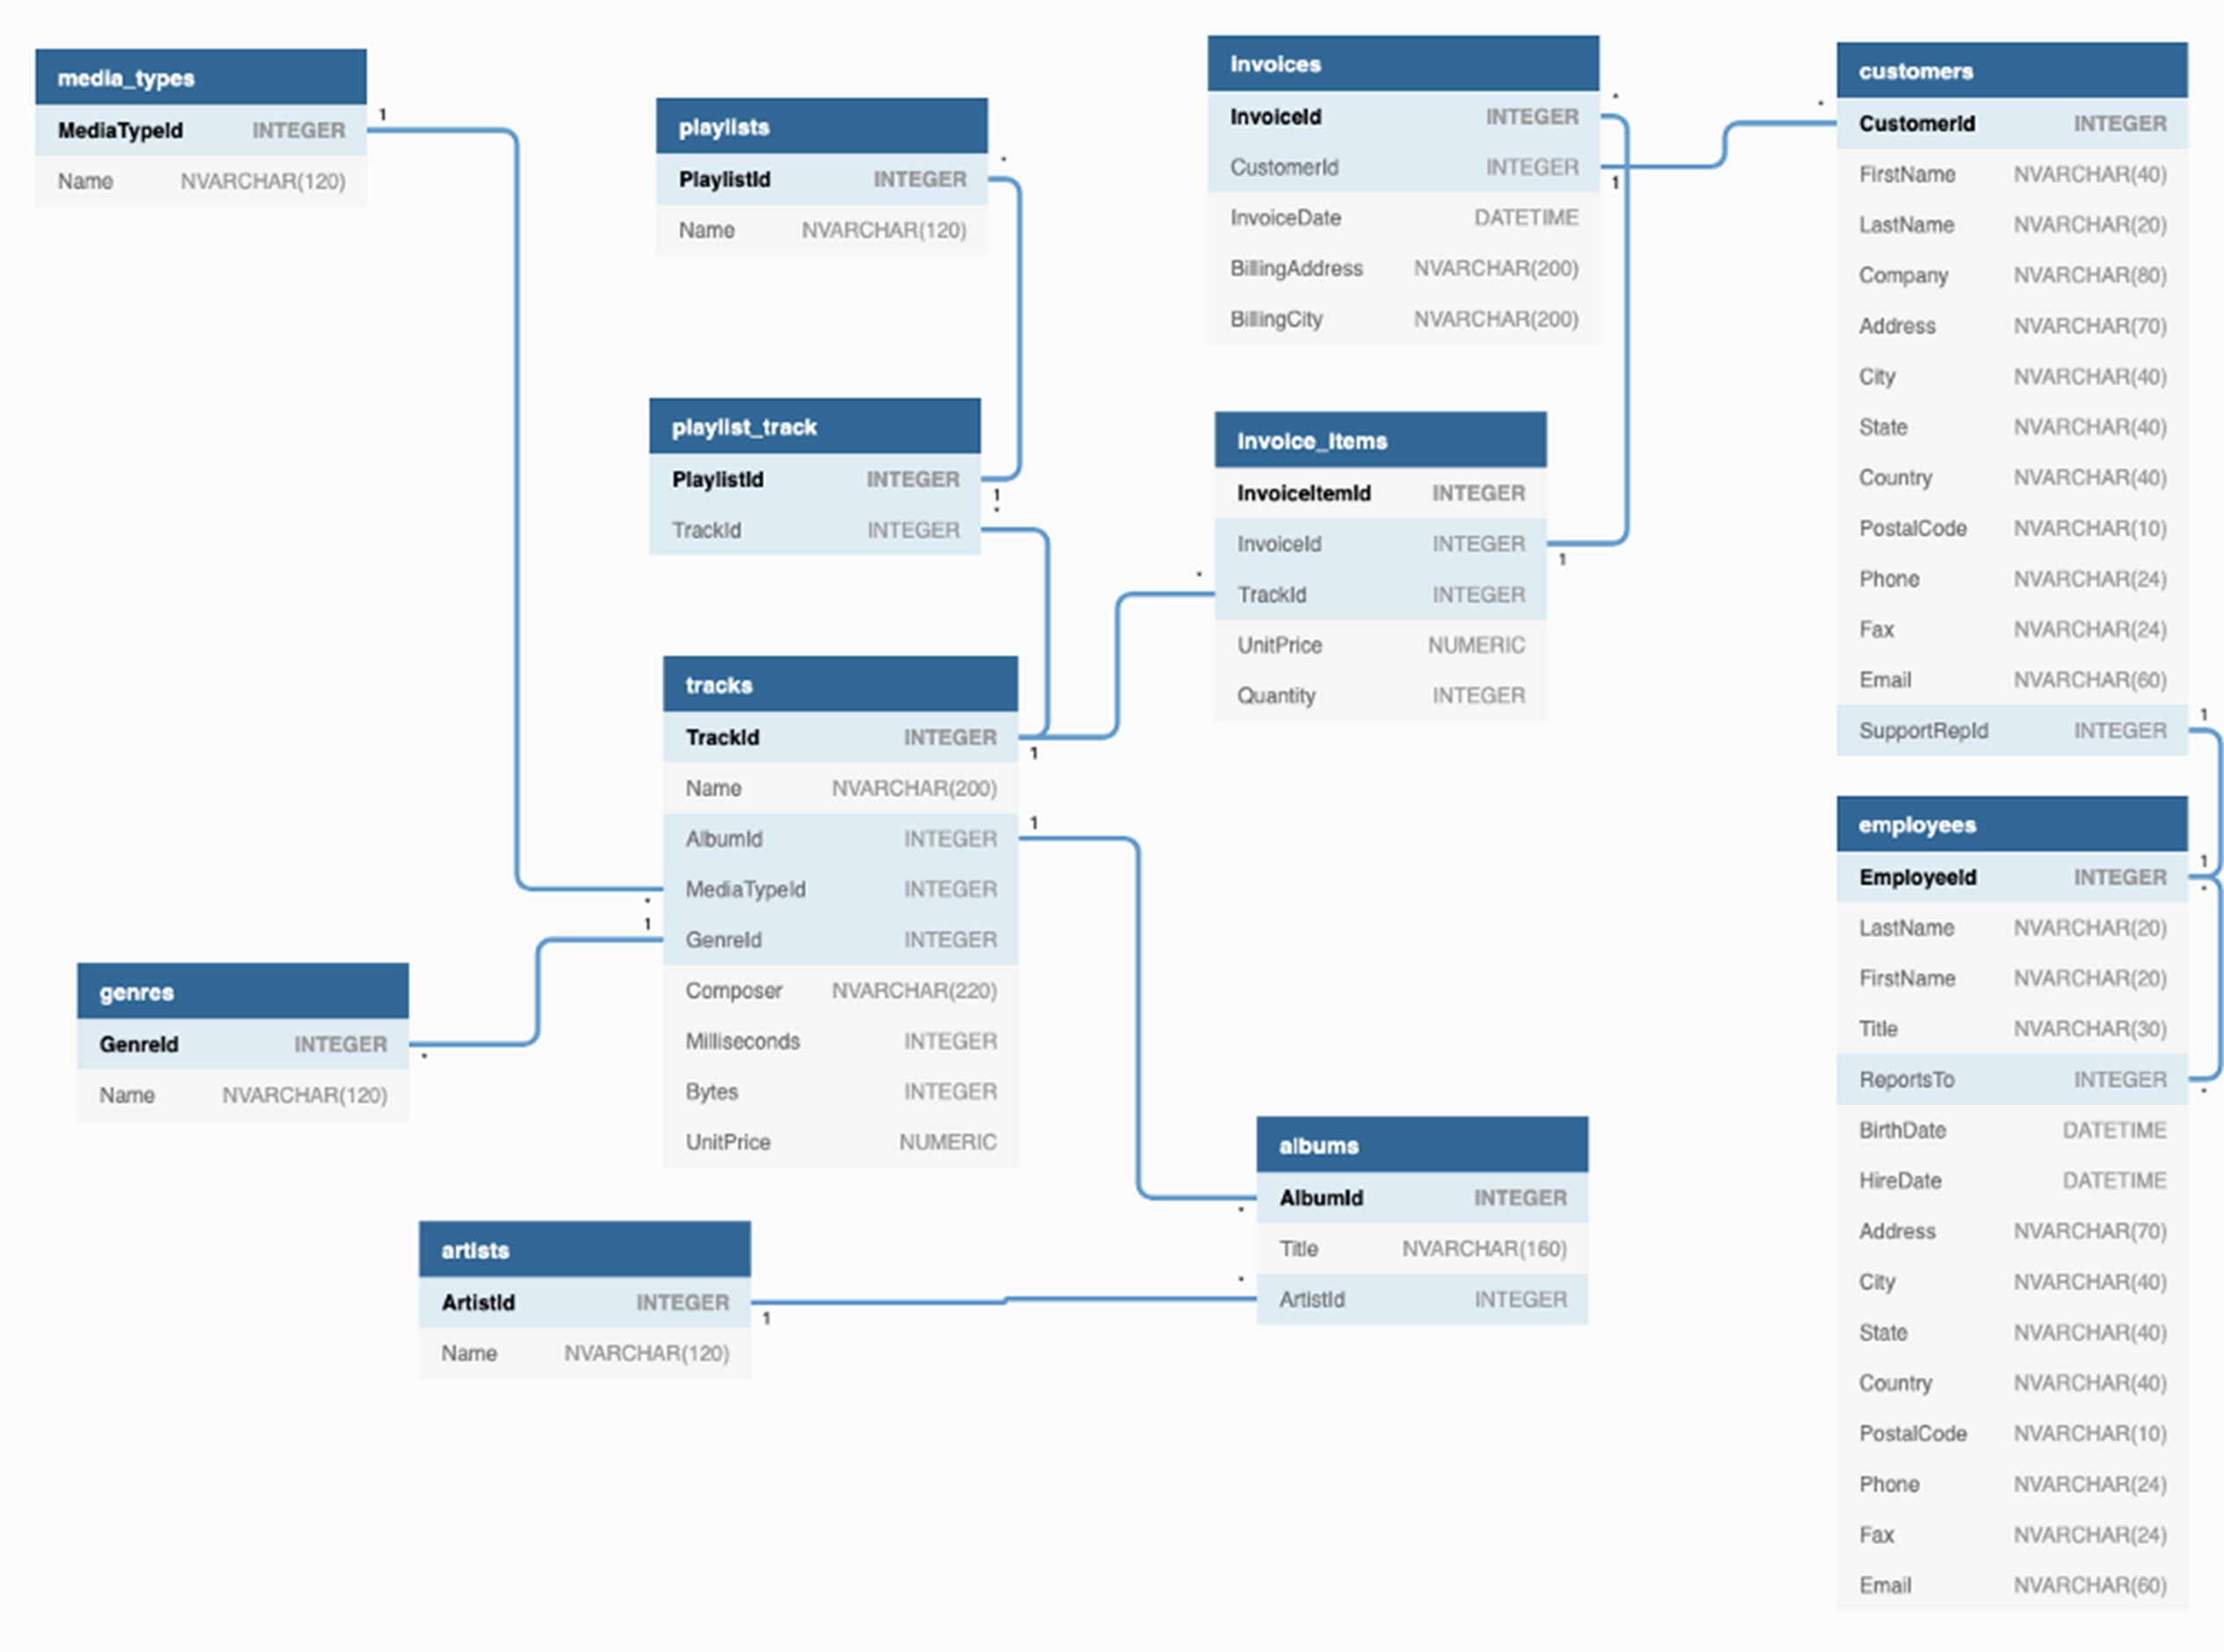

### Primeras queries con SELECT

De la sesión de introducción recordarás que la sintáxis básica de una sentencia o query SELECT tiene esta pinta:
```SQL
SELECT campo1, campo2, campo3...
FROM tabla
WHERE condiciones
ORDER BY campo1, campo2 (DESC)
LIMIT num_filas
```

Por supuesto, hay más sentencias propias de SQL que iremos viendo a lo largo de la unidad, y del bootcamp. Fíjate que las **palabras reservadas en SQL se suelen poner en mayúsculas**, para diferenciarlas del resto. No da error si se pone de otra manera, ya que SQL **no es *case sensitive***, pero sí se suele hacer así.

En lo que queda de sesión vamos a hacer nuestras primeras queries, muy sencillas, para que vayas familiarizandote y ya en los ejercicios tendrás mucho donde practicar.

#### SELECT *

Ya la hicimos sobre la tabla `employees` en la sesión anterior provemos ahora con otras tablas

In [3]:
query = '''
SELECT * 
FROM tracks
'''

Como puedes ver se suele utilizar las triple comilla y la consulta en varias líneas segúna la parte del SELECT que corresponda, pero no es imperativo, puedes poner toda la sentencia en una sóla línea tal y como hemos hecho al consultar el nombre de todas las tablas contenidas en la base de datos. Completemos la ejecución y volquemos a un `DataFrame` tal y como vimos:

In [7]:
cursor_bootcamp.execute(query)
resultado = cursor_bootcamp.fetchall()
col = [d[0] for d in cursor_bootcamp.description]
df = pd.DataFrame(resultado, columns = col)
df


,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,None,342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99
...,...,...,...,...,...,...,...,...,...
3498,3499,Pini Di Roma (Pinien Von Rom) \ I Pini Della V...,343,2,24,None,286741,4718950,0.99
3499,3500,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",344,2,24,Franz Schubert,139200,2283131,0.99
3500,3501,"L'orfeo, Act 3, Sinfonia (Orchestra)",345,2,24,Claudio Monteverdi,66639,1189062,0.99
3501,3502,"Quintet for Horn, Violin, 2 Violas, and Cello ...",346,2,24,Wolfgang Amadeus Mozart,221331,3665114,0.99


### Selección de campos

Seleccionemos ahora algunos campos únicamente y además cambiémosle el nombre al vuelo, mediante la sintaxis `campo as nuevo_nombre`. **Si quieres poner espacios en el nombre del campo, tendrás que rodear el string con comillas dobles**

Y recuerda: SQL no es sensible a mayusculas y minusculas. ("este_CampO" == "ESTE_CAMPO")

In [8]:
query = '''
SELECT Name as "Nombre Cancion", composer as "Compositor"
FROM tracks'''

cursor_bootcamp.execute(query)
resultado = cursor_bootcamp.fetchall()
col = [d[0] for d in cursor_bootcamp.description]
df = pd.DataFrame(resultado, columns = col)
df


,Nombre Cancion,Compositor
0,For Those About To Rock (We Salute You),"Angus Young, Malcolm Young, Brian Johnson"
1,Balls to the Wall,None
2,Fast As a Shark,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho..."
3,Restless and Wild,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D..."
4,Princess of the Dawn,Deaffy & R.A. Smith-Diesel
...,...,...
3498,Pini Di Roma (Pinien Von Rom) \ I Pini Della V...,None
3499,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",Franz Schubert
3500,"L'orfeo, Act 3, Sinfonia (Orchestra)",Claudio Monteverdi
3501,"Quintet for Horn, Violin, 2 Violas, and Cello ...",Wolfgang Amadeus Mozart


### LIMIT y DISTINCT

Para terminar la sesión veamos como usar dos modicadores LIMIT (que ya vimos en la introducción teórica) y DISTINCT (que es el equivalete del método `unique` en pandas)

#### LIMIT
Se usa para acotar el número de registros de la query. Va siempre al final. Por ejemplo `LIMIT 10`

In [9]:
query = '''
SELECT Name as "Nombre Cancion"
FROM tracks
LIMIT 10
'''
cursor_bootcamp.execute(query)
resultado = cursor_bootcamp.fetchall()
col = [d[0] for d in cursor_bootcamp.description]
df = pd.DataFrame(resultado, columns = col)
df

,Nombre Cancion
0,For Those About To Rock (We Salute You)
1,Balls to the Wall
2,Fast As a Shark
3,Restless and Wild
4,Princess of the Dawn
5,Put The Finger On You
6,Let's Get It Up
7,Inject The Venom
8,Snowballed
9,Evil Walks


#### DISTINCT
Se usa para obtener todos los registros únicos, es decir, sin duplicados. Lo podremos emplear para eliminar dupicados (aunque te recomiendo que no modifiques los datos de las bases de datos, vuelcalo a pandas y modifica ahí), como para ver todas las casuísticas de un campo en concreto.

**Mucho cuidado con esta sentencia ya que si la tabla tiene miles o millones de registros, puede ralentizar mucho la query.**

In [10]:
query = '''
SELECT DISTINCT Composer
FROM tracks
'''
cursor_bootcamp.execute(query)
resultado = cursor_bootcamp.fetchall()
col = [d[0] for d in cursor_bootcamp.description]
df = pd.DataFrame(resultado, columns = col)
df

,Composer
0,"Angus Young, Malcolm Young, Brian Johnson"
1,None
2,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho..."
3,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D..."
4,Deaffy & R.A. Smith-Diesel
...,...
848,Carl Nielsen
849,Niccolò Paganini
850,Pietro Antonio Locatelli
851,Claudio Monteverdi
